# Notebook 04 - Red neuronal recurrente (RNN)

En este notebook implementamos una RNN simple para clasificar actividades humanas a partir de señales de sensores tratadas como secuencias temporales.

## 1. Importaciones

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time
import json
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

np.random.seed(42)
tf.random.set_seed(42)
print('Listo')

Listo


## 2. Carga de datos

In [2]:
DATA_DIR = '../data/processed'

X_tr = np.load(os.path.join(DATA_DIR, 'X_tr_seq.npy'))
X_val = np.load(os.path.join(DATA_DIR, 'X_val_seq.npy'))
X_test = np.load(os.path.join(DATA_DIR, 'X_test_seq.npy'))

y_tr = np.load(os.path.join(DATA_DIR, 'y_tr_seq.npy'))
y_val = np.load(os.path.join(DATA_DIR, 'y_val_seq.npy'))
y_test = np.load(os.path.join(DATA_DIR, 'y_test_seq.npy'))

y_test_int = np.load(os.path.join(DATA_DIR, 'y_test_int.npy'))

nombres_clases = ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']

print('Train:', X_tr.shape)
print('Validation:', X_val.shape)
print('Test:', X_test.shape)

Train: (5881, 128, 9)
Validation: (1471, 128, 9)
Test: (2947, 128, 9)


## 3. ¿Qué es una RNN?

Una RNN (Red Neuronal Recurrente) procesa secuencias manteniendo un estado oculto que se pasa de un paso de tiempo al siguiente. En cada paso:

```
h_t = tanh(W_h * h_(t-1) + W_x * x_t + b)
```

Donde `h_t` es el estado oculto actual, `h_(t-1)` es el estado anterior y `x_t` es la entrada actual.

Esto permite que la red tenga "memoria" de los pasos anteriores, lo cual es útil para datos secuenciales como señales de sensores.

## 4. Arquitectura de la RNN

In [3]:
modelo_rnn = Sequential([
    # Primera capa RNN (retorna secuencia para poder apilar otra RNN)
    SimpleRNN(64, activation='tanh', return_sequences=True, input_shape=(128, 9)),
    Dropout(0.2),

    # Segunda capa RNN
    SimpleRNN(32, activation='tanh', return_sequences=False),
    Dropout(0.2),

    # Capa densa final
    Dense(32, activation='relu'),

    # Salida
    Dense(6, activation='softmax')
])

modelo_rnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 128, 64)        │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,094 (35.52 KB)

 Trainable params: 9,094 (35.52 KB)

 Non-trainable params: 0 (0.00 B)

Usamos dos capas `SimpleRNN`. La primera tiene `return_sequences=True` para que devuelva el estado oculto en cada paso de tiempo (necesario para alimentar la segunda capa RNN). La segunda capa tiene `return_sequences=False` y devuelve solo el estado final.

## 5. Entrenamiento

In [4]:
modelo_rnn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

inicio = time.time()

historial = modelo_rnn.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=80,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

tiempo_entrenamiento = time.time() - inicio
print(f'\nTiempo de entrenamiento: {tiempo_entrenamiento:.2f} segundos')

Epoch 1/80
92/92 ━━━━━━━━━━━━━━━━━━━━ 15s 82ms/step - accuracy: 0.5254 - loss: 1.2023 - val_accuracy: 0.6451 - val_loss: 0.7483
Epoch 2/80
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - accuracy: 0.6225 - loss: 0.8069 - val_accuracy: 0.6730 - val_loss: 0.7102
Epoch 3/80
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - accuracy: 0.6722 - loss: 0.6915 - val_accuracy: 0.7362 - val_loss: 0.5979
Epoch 4/80
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.7461 - loss: 0.5933 - val_accuracy: 0.7138 - val_loss: 0.6180
Epoch 5/80
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.7300 - loss: 0.6149 - val_accuracy: 0.7695 - val_loss: 0.5303
Epoch 6/80
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - accuracy: 0.7978 - loss: 0.5005 - val_accuracy: 0.8810 - val_loss: 0.3389
Epoch 7/80
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - accuracy: 0.7837 - loss: 0.5353 - val_accuracy: 0.8416 - val_loss: 0.4130
Epoch 8/80
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - accuracy: 0.7150 - loss: 0.7014 - val_accuracy: 0.8402 - 

## 6. Curvas de aprendizaje

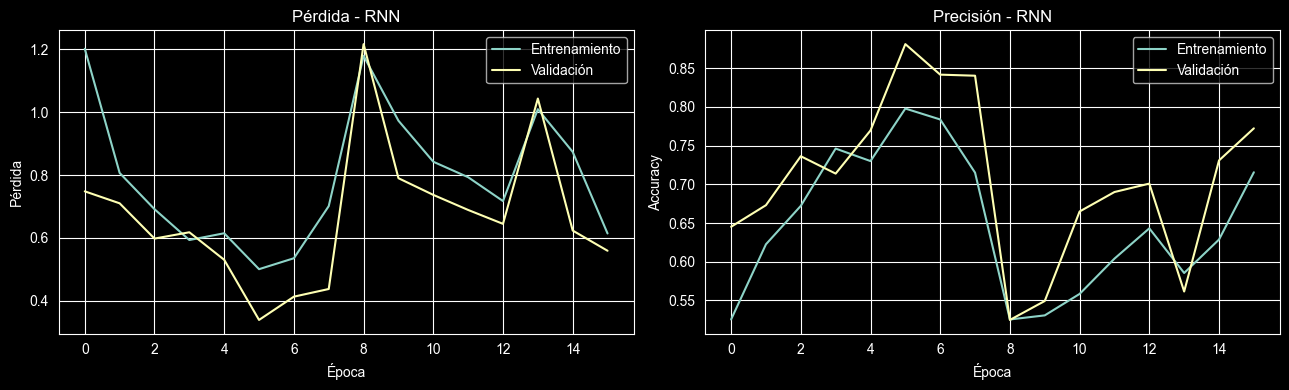

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(historial.history['loss'], label='Entrenamiento')
axes[0].plot(historial.history['val_loss'], label='Validación')
axes[0].set_title('Pérdida - RNN')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Pérdida')
axes[0].legend()

axes[1].plot(historial.history['accuracy'], label='Entrenamiento')
axes[1].plot(historial.history['val_accuracy'], label='Validación')
axes[1].set_title('Precisión - RNN')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/curvas_rnn.png', dpi=100, bbox_inches='tight')
plt.show()

## 7. Evaluación

In [6]:
y_pred_prob = modelo_rnn.predict(X_test)
y_pred_int = np.argmax(y_pred_prob, axis=1)

acc = accuracy_score(y_test_int, y_pred_int)
print(f'Accuracy en Test: {acc:.4f}\n')
print(classification_report(y_test_int, y_pred_int, target_names=nombres_clases))

93/93 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step
Accuracy en Test: 0.8317

                    precision    recall  f1-score   support

           WALKING       0.79      0.88      0.83       496
  WALKING_UPSTAIRS       0.78      0.74      0.76       471
WALKING_DOWNSTAIRS       0.82      0.82      0.82       420
           SITTING       0.81      0.76      0.78       491
          STANDING       0.80      0.83      0.81       532
            LAYING       0.99      0.95      0.97       537

          accuracy                           0.83      2947
         macro avg       0.83      0.83      0.83      2947
      weighted avg       0.83      0.83      0.83      2947



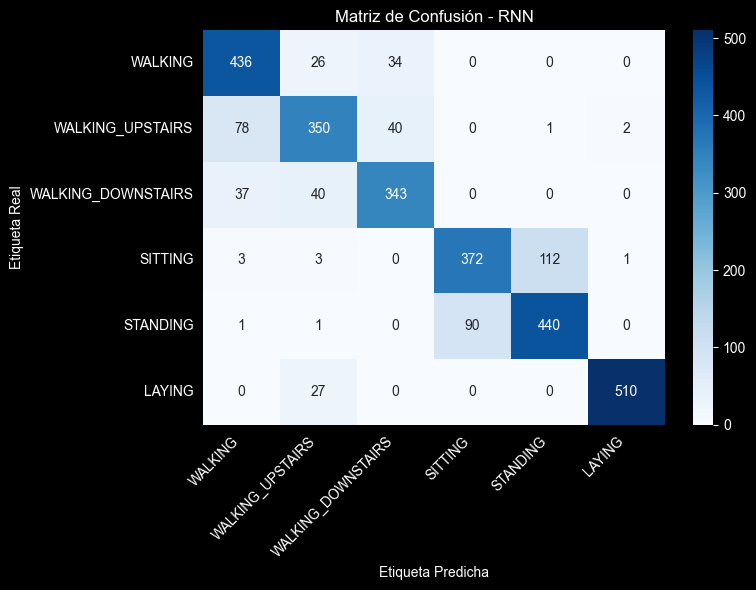

In [7]:
cm = confusion_matrix(y_test_int, y_pred_int)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=nombres_clases, yticklabels=nombres_clases)
plt.title('Matriz de Confusión - RNN')
plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../reports/cm_rnn.png', dpi=100, bbox_inches='tight')
plt.show()

In [8]:
metricas_rnn = {
    'modelo': 'RNN',
    'accuracy': accuracy_score(y_test_int, y_pred_int),
    'precision': precision_score(y_test_int, y_pred_int, average='weighted'),
    'recall': recall_score(y_test_int, y_pred_int, average='weighted'),
    'f1': f1_score(y_test_int, y_pred_int, average='weighted'),
    'tiempo_entrenamiento': tiempo_entrenamiento
}

for k, v in metricas_rnn.items():
    print(f'  {k}: {v:.4f}' if isinstance(v, float) else f'  {k}: {v}')

with open('../models/metricas_rnn.json', 'w') as f:
    json.dump(metricas_rnn, f)

modelo_rnn.save('../models/modelo_rnn.keras')
print('\nGuardado.')

  modelo: RNN
  accuracy: 0.8317
  precision: 0.8335
  recall: 0.8317
  f1: 0.8318
  tiempo_entrenamiento: 105.9177

Guardado.


## Conclusiones del modelo RNN

La RNN simple tiene la capacidad de capturar dependencias temporales, pero presenta una limitación importante conocida como el **problema del gradiente desvaneciente**:

- Durante el backpropagation a través del tiempo (BPTT), los gradientes se multiplican en cada paso temporal.
- Si la secuencia es larga (128 pasos en nuestro caso), estos gradientes tienden a hacerse muy pequeños.
- Como resultado, la RNN "olvida" información de los pasos más lejanos.

Este es el problema que LSTM y GRU resuelven mediante compuertas (gates) especiales. En el siguiente notebook veremos cómo la LSTM supera esta limitación.